<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/GOOGLE_PLAY_STORE_APPS_DATA_ANALYSIS_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GOOGLE PLAY STORE APPS DATA ANALYSIS PROJECT**


**STEP 1 :- IMPORT LIBRARIES**


In [ ]:
##STEP 1:- IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Markdown
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


**STEP 2:-LOADING DATABASE**


In [ ]:
#LOADING DATABASE
apps_df=pd.read_csv("googleplaystore.csv")
reviews_df=pd.read_csv("googleplaystore_user_reviews.csv")
print("App Dataset Shape:",apps_df.shape)
print("User Reviews Dataset Shape:",reviews_df.shape)
apps_df.head()

App Dataset Shape: (10841, 13)
User Reviews Dataset Shape: (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**STEP 3:-EXPLORE BASIC INFO**

In [ ]:
#EXPLORE INFORMATION
print("\nDataset Information")
print(apps_df.info())

print("\nMissing Values")
print(apps_df.isnull().sum())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None

Missing Values
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Instal

**STEP 4:- CLEAN THE DATA**

In [ ]:
#CLEAN DATA
apps_df.drop_duplicates(subset='App',inplace=True)
apps_df['Rating'].fillna(apps_df['Rating'].mean(),inplace=True)

**STEP 5:- HANDLE THE 'FREE' VALUES IN 'INSTALLS' BEFORE CONVERTING TO FLOAT**


In [ ]:
# HANDLE DATA
apps_df=apps_df[apps_df['Installs']!='Free']
apps_df['Installs']=apps_df['Installs'].str.replace('+','',regex=False).str.replace(',','',regex=False).astype(float)
apps_df['Price']=apps_df['Price'].str.replace('$','',regex=False).astype(float)
apps_df['Reviews']=pd.to_numeric(apps_df['Reviews'],errors='coerce').fillna(0).astype(int)

def convert_size(size):
  if'M'in str(size):
    return float(size.replace('M',''))*1024
  elif 'k' in str(size):
    return float(size.replace('k',''))
  else:
    return np.nan
apps_df['Size_KB']=apps_df['Size'].apply(convert_size)


**STEP 5:-SUMMARY STATISTICS**

In [ ]:
#SUMMARIZING
print("\n Summary Of Numeric Columns:")
print(apps_df.describe())


 Summary Of Numeric Columns:
            Rating       Reviews      Installs        Price        Size_KB
count  9659.000000  9.659000e+03  9.659000e+03  9659.000000    8432.000000
mean      4.173517  2.165926e+05  7.777507e+06     1.099299   20884.374134
std       0.494313  1.831320e+06  5.375828e+07    16.852152   22351.767303
min       1.000000  0.000000e+00  0.000000e+00     0.000000       8.500000
25%       4.000000  2.500000e+01  1.000000e+03     0.000000    4710.400000
50%       4.200000  9.670000e+02  1.000000e+05     0.000000   12288.000000
75%       4.500000  2.940100e+04  1.000000e+06     0.000000   28672.000000
max       5.000000  7.815831e+07  1.000000e+09   400.000000  102400.000000


**STEP 6:- DATA VISUALIZATION**

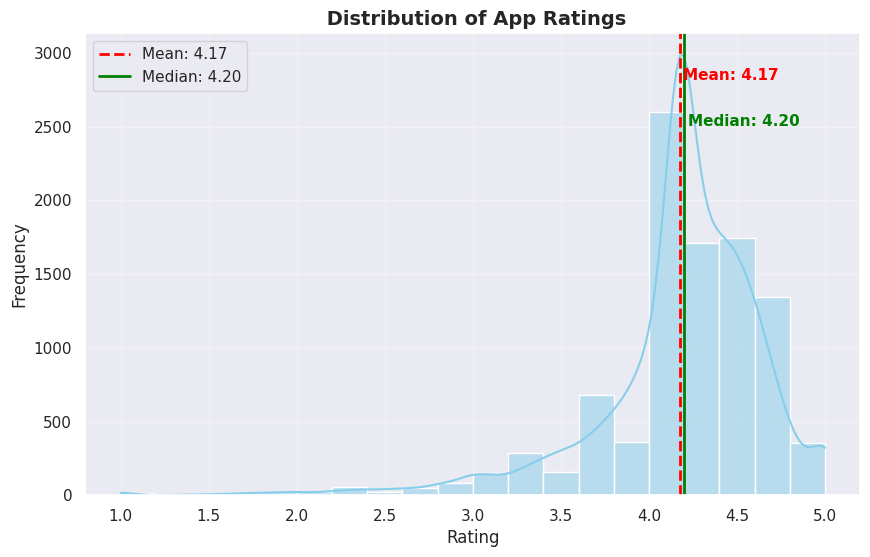

In [ ]:
#VISUALIZATION
plt.figure(figsize=(10,6))

# Histogram
sns.histplot(apps_df['Rating'], bins=20, kde=True, color='skyblue')

# Calculate mean & median
mean_rating = apps_df['Rating'].mean()
median_rating = apps_df['Rating'].median()

# Add vertical lines
plt.axvline(mean_rating, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='-', linewidth=2, label=f'Median: {median_rating:.2f}')

# Add text annotations next to the lines
plt.text(mean_rating + 0.02, plt.ylim()[1]*0.9, f"Mean: {mean_rating:.2f}", color='red', fontsize=11, fontweight='bold')
plt.text(median_rating + 0.02, plt.ylim()[1]*0.8, f"Median: {median_rating:.2f}", color='green', fontsize=11, fontweight='bold')

# Titles and labels
plt.title(' Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


** APP CATEGORIES (TOP 10)**

In [ ]:


# Prepare top 10 categories and percentages
category_counts = apps_df['Category'].value_counts().head(10)
category_percent = (category_counts / apps_df['Category'].count()) * 100

# Create subplot layout (1 row, 2 columns)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("🏆 Top 10 App Categories by Count", "📱 Category Percentage Share"),
    specs=[[{"type": "bar"}, {"type": "pie"}]]
)

# --- BAR CHART ---
fig.add_trace(
    go.Bar(
        x=category_counts.index,
        y=category_counts.values,
        text=[f"{p:.1f}%" for p in category_percent],
        textposition='auto',
        marker_color='coral',
        hovertemplate="<b>%{x}</b><br>Apps: %{y}<br>Share: %{text}<extra></extra>"
    ),
    row=1, col=1
)

# --- PIE CHART ---
fig.add_trace(
    go.Pie(
        labels=category_counts.index,
        values=category_counts.values,
        textinfo='label+percent',
        hoverinfo='label+percent+value',
        marker=dict(line=dict(color='black', width=1))
    ),
    row=1, col=2
)

# --- Layout Settings ---
fig.update_layout(
    title_text="📊 App Category Analysis (Top 10)",
    title_x=0.5,
    showlegend=False,
    template="plotly_white",
    height=600,
)

fig.show()



**RATING VS INSTALL**

In [ ]:


# Create two histograms using Plotly Graph Objects
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(" Distribution of App Ratings", " Distribution of App Installs")
)

# --- HISTOGRAM 1: App Ratings ---
fig.add_trace(
    go.Histogram(
        x=apps_df['Rating'],
        nbinsx=20,
        marker_color='skyblue',
        opacity=0.75,
        name='App Rating'
    ),
    row=1, col=1
)

# --- HISTOGRAM 2: App Installs ---
fig.add_trace(
    go.Histogram(
        x=apps_df['Installs'],
        nbinsx=30,
        marker_color='coral',
        opacity=0.75,
        name='App Installs'
    ),
    row=1, col=2
)

# --- Layout customization ---
fig.update_layout(
    title_text=" Comparison of App Ratings and Installs",
    title_x=0.5,
    template='plotly_white',
    bargap=0.05,
    showlegend=False,
    height=600
)

# --- Axis labels ---
fig.update_xaxes(title_text="Rating", row=1, col=1)
fig.update_yaxes(title_text="Number of Apps", row=1, col=1)
fig.update_xaxes(title_text="Installs", row=1, col=2)
fig.update_yaxes(title_text="Number of Apps", row=1, col=2)

# --- Show figure ---
fig.show()


**AVERAGE RATING**

In [ ]:
# Calculate averages
avg_metrics = (
    apps_df.groupby('Category')[['Rating', 'Installs']]
    .mean()
    .sort_values('Rating', ascending=False)
    .head(10)
    .reset_index()
)

# Create figure
fig = go.Figure()

# Add average rating bars
fig.add_trace(go.Bar(
    x=avg_metrics['Category'],
    y=avg_metrics['Rating'],
    name='Average Rating ⭐',
    marker_color='mediumseagreen',
    yaxis='y1'
))

# Add average installs bars (secondary axis)
fig.add_trace(go.Bar(
    x=avg_metrics['Category'],
    y=avg_metrics['Installs'],
    name='Average Installs 📲',
    marker_color='lightskyblue',
    yaxis='y2'
))

# Update layout with dual y-axes
fig.update_layout(
    title='Comparison of Average Rating vs Average Installs by Category (Top 10)',
    xaxis_title='App Category',
    yaxis=dict(title='Average Rating', side='left', showgrid=False),
    yaxis2=dict(title='Average Installs', side='right', overlaying='y'),
    barmode='group',
    template='plotly_white',
    height=600,
    title_x=0.5
)

fig.show()

** STEP 7: KEY INSIGHTS**


In [ ]:
# 📊 KEY INSIGHTS SUMMARY (CLEAN TABLE VERSION)

# Compute key metrics
total_apps = len(apps_df)
avg_rating = round(apps_df['Rating'].mean(), 2)
median_rating = round(apps_df['Rating'].median(), 2)
top_category = apps_df['Category'].value_counts().idxmax()
most_installed_app = apps_df.loc[apps_df['Installs'].idxmax(), 'App']
most_installed_value = int(apps_df['Installs'].max())
total_installs = int(apps_df['Installs'].sum())

# Create summary DataFrame
summary_df = pd.DataFrame({
    "Metric": [
        "Total Apps Analyzed",
        "Average App Rating",
        "Median App Rating",
        "Most Popular Category",
        "Most Installed App",
        "Most Installed App (Installs)",
        "Total Installs (All Apps)"
    ],
    "Value": [
        f"{total_apps:,}",
        avg_rating,
        median_rating,
        top_category,
        most_installed_app,
        f"{most_installed_value:,}",
        f"{total_installs:,}"
    ]
})

# Display as styled table
summary_df.style.set_caption("App Dataset — Key Insights").hide(axis="index")



Metric,Value
Total Apps Analyzed,"9,659"
Average App Rating,4.170000
Median App Rating,4.200000
Most Popular Category,FAMILY
Most Installed App,Google Play Books
Most Installed App (Installs),"1,000,000,000"
Total Installs (All Apps),"75,122,937,527"


**MERGE THE USER REVIEW**



Merged dataset shape: (61556, 18)

Merged dataset preview:
                   App Sentiment
0  Coloring book moana  Negative
1  Coloring book moana  Negative
2  Coloring book moana   Neutral
3  Coloring book moana       NaN
4  Coloring book moana  Positive


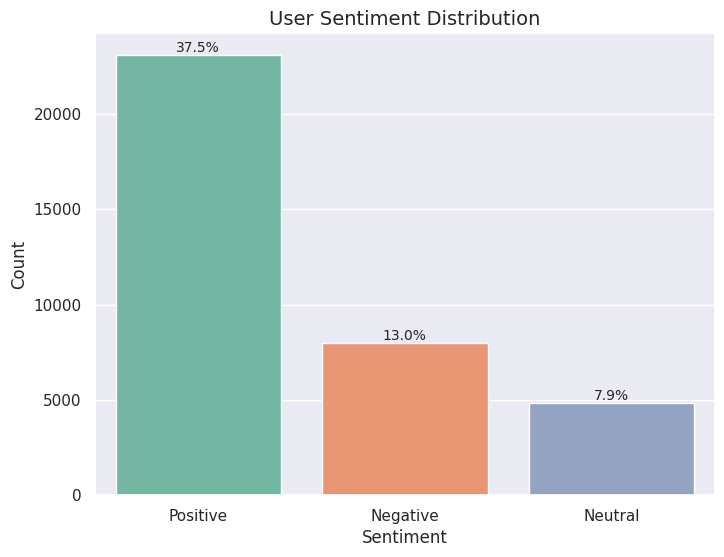

In [ ]:
# STEP: MERGE APP AND REVIEW DATASETS
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')
print("\nMerged dataset shape:", merged_df.shape)

# Check merged data
print("\nMerged dataset preview:")
print(merged_df[['App', 'Sentiment']].head())

# STEP: SENTIMENT DISTRIBUTION
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Sentiment', data=merged_df, palette='Set2', order=merged_df['Sentiment'].value_counts().index)

# Add percentage labels on bars
total = len(merged_df)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('User Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()
